In [ ]:
EMA_path = "./../inference/combined/EMA.json"
JAPAN_path = "./../inference/combined/JAPAN.json"
SWISSMEDIC_path = "./../inference/combined/SWISSMEDIC.json"
# AUSTRALIA_path = "./../inference/combined/AUSTRALIA.json"

SAVE_DIR = "./../inference/combined/figures/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

In [ ]:
def load_data(file_path):
    """Load data from a JSON file."""
    with open(file_path, 'r') as file:
        data = json.load(file)
    return pd.DataFrame(data)

def to_lower(df):
    return df.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

def remove_invalid_rows(df):
    invalid_rows = df.apply(lambda x: x.astype(str).str.contains("the response is not valid json", case=False, na=False))
    print(f"Total rows with invalid responses: {invalid_rows.any(axis=1).sum()}")
    df = df[~invalid_rows.any(axis=1)]
    return df

def prepare_for_analysis(filepath):
    df = load_data(filepath)
    df = df.transpose()
    df = remove_invalid_rows(df)
    df = to_lower(df)
    return df

def date_to_int(df, col_name):
    original_len = len(df)
    df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
    df[col_name] = df[col_name].dt.year
    df = df.dropna(subset=[col_name]).astype({col_name: 'int'})
    final_len = len(df)
    print(f"Original length: {original_len}, Final length after cleaning: {final_len}, Percentage kept: {final_len/original_len*100:.2f}%")
    return df

def plot_timeline(df, col_name, dataset_name=None):
    df = date_to_int(df, col_name)  # Ensure column is integer (e.g., year)
    unique_vals = sorted(df[col_name].unique())
    bins = np.append(unique_vals, unique_vals[-1] + 1)
    plt.figure(figsize=(8, 4))
    ax = plt.gca()
    counts, edges, patches = plt.hist(df[col_name], bins=bins, color="seagreen", edgecolor='black', align='left', alpha=0.7)
    ax.set_xticks(unique_vals)
    ax.set_xticklabels([str(int(x)) for x in unique_vals], rotation=45, ha='center')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_{col_name}_timeline.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_distribution(df, drug_class_colormap=None, dataset_name=None):
    class_order = df['Drug_class'].value_counts().index
    palette = {cls: drug_class_colormap[cls] for cls in class_order}


    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 0.5,
            s=int(height),
            ha='center', va='bottom', fontsize=9
        )
    plt.xticks(rotation=45, ha='right')
    # plt.title('Distribution of Drug Classes')
    plt.xlabel('Drug Class')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_distribution_pie(df, drug_class_colormap=None, dataset_name=None):
    class_counts = df['Drug_class'].value_counts()
    cmap = plt.get_cmap('tab20')
    labels = class_counts.index
    sizes = class_counts.values
    colors = [drug_class_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(5, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )
    legend_labels = [f"{label} ({size / total * 100:.1f}%)" for label, size in zip(labels, sizes)]

    plt.legend(
        wedges,
        legend_labels,
        title='Drug Class',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    # plt.title('Distribution of Drug Classes')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_distribution_pie.png", dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
EMA = prepare_for_analysis(EMA_path)
JAPAN = prepare_for_analysis(JAPAN_path)
SWISSMEDIC = prepare_for_analysis(SWISSMEDIC_path)

Total rows with invalid responses: 5
Total rows with invalid responses: 0
Total rows with invalid responses: 0


In [410]:
all_classes = pd.concat([EMA['Drug_class'], JAPAN['Drug_class'], SWISSMEDIC['Drug_class']]).unique()
print("All unique drug classes across datasets:", all_classes)
cmap = plt.get_cmap('tab20')
colors = cmap(np.linspace(0, 1, len(all_classes)))
drug_class_colormap = dict(zip(all_classes, colors))

All unique drug classes across datasets: ['small molecule' 'biologics' 'peptides and proteins' 'other' 'vaccine'
 'cell and gene therapy' 'vitamins' 'antibiotic' 'antibiotics'
 'antibody-drug conjugate' 'gene therapy' 'antisense oligonucleotide'
 'oligonucleotide']


In [411]:
EMA.columns

Index(['Marketing_authorisation_number', 'Procedure_number', 'Drug_name',
       'Non_proprietary_name', 'Marketing_authorisation_holder', 'Drug_class',
       'Pharmaceutical_form', 'Administration_route', 'Decision',
       'Current_status', 'Decision_date', 'Decision_year',
       'Orphan_drug_status', 'Indication_extended', 'Indication_requested',
       'Indication_approved', 'Disease_class(es)', 'Application_date',
       'Application_year', 'Nonclinical_abridged', 'Referral_body',
       'Document_name'],
      dtype='object')

Original length: 1832, Final length after cleaning: 1566, Percentage kept: 85.48%


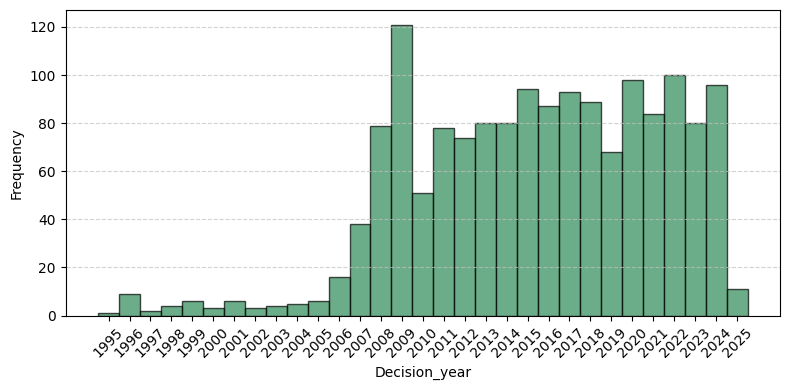

Original length: 378, Final length after cleaning: 378, Percentage kept: 100.00%


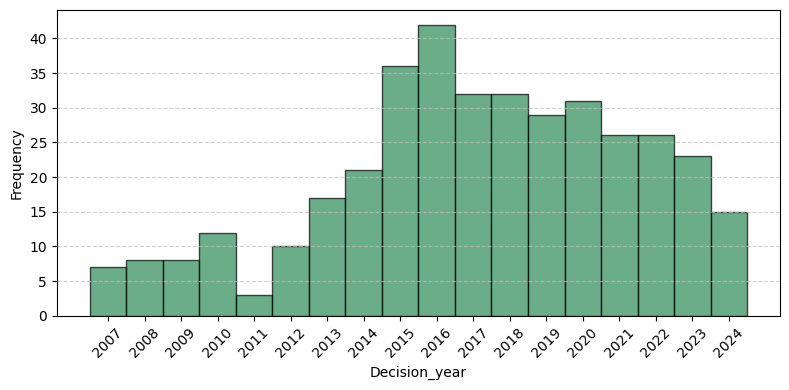

Original length: 170, Final length after cleaning: 170, Percentage kept: 100.00%


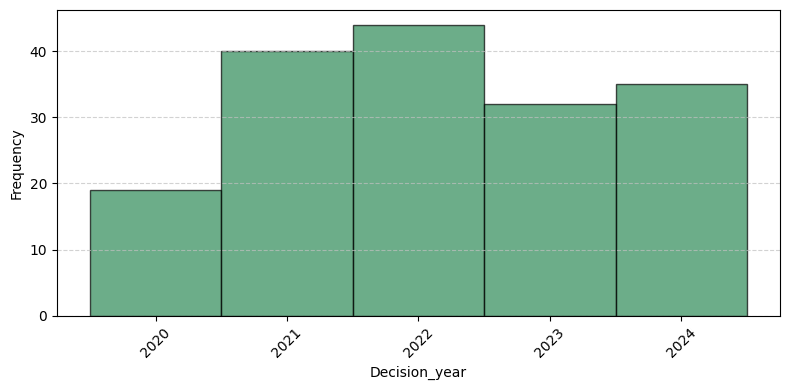

In [412]:
plot_timeline(EMA, col_name='Decision_year', dataset_name='EMA')
plot_timeline(JAPAN, col_name='Decision_year', dataset_name='JAPAN')
plot_timeline(SWISSMEDIC, col_name='Decision_year', dataset_name='SWISSMEDIC')

Original length: 1832, Final length after cleaning: 1391, Percentage kept: 75.93%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_25088\3109909329.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col_name] = pd.to_datetime(df[col_name], errors='coerce')


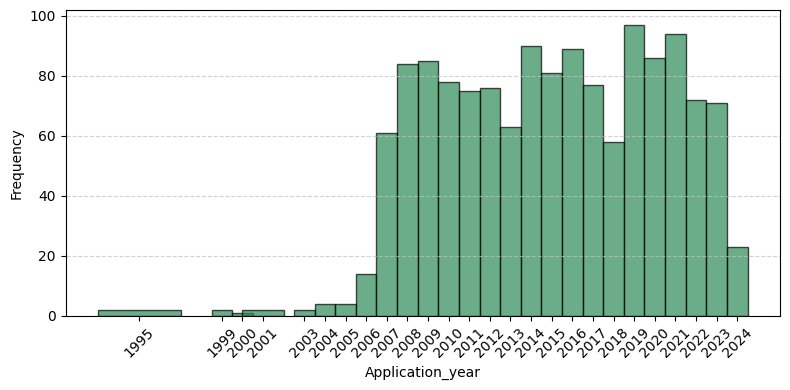

Original length: 378, Final length after cleaning: 378, Percentage kept: 100.00%


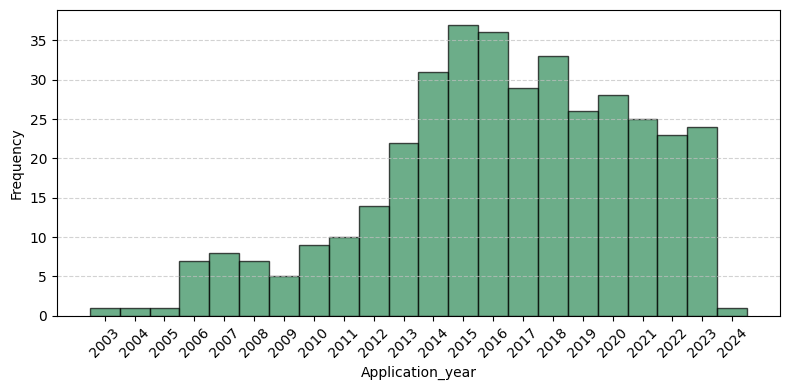

Original length: 170, Final length after cleaning: 170, Percentage kept: 100.00%


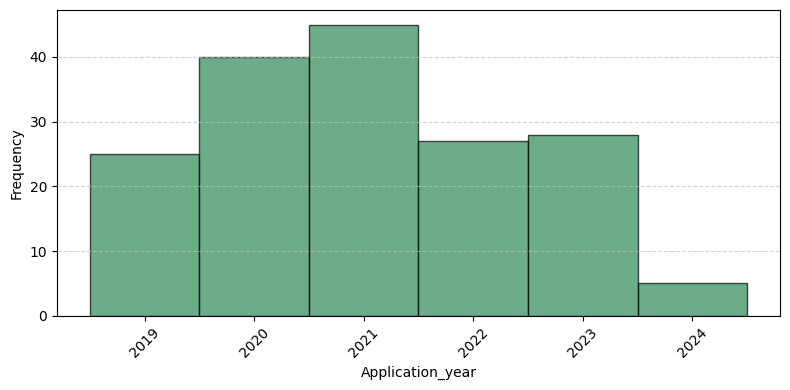

In [413]:
plot_timeline(EMA, col_name='Application_year', dataset_name='EMA')
plot_timeline(JAPAN, col_name='Application_year', dataset_name='JAPAN')
plot_timeline(SWISSMEDIC, col_name='Application_year', dataset_name='SWISSMEDIC')

In [414]:
EMA["Drug_class"].unique()

array(['small molecule', 'biologics', 'peptides and proteins', 'other',
       'vaccine', 'cell and gene therapy', 'vitamins', 'antibiotic',
       'antibiotics', 'antibody-drug conjugate', 'gene therapy',
       'antisense oligonucleotide', 'oligonucleotide'], dtype=object)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_25088\3109909329.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


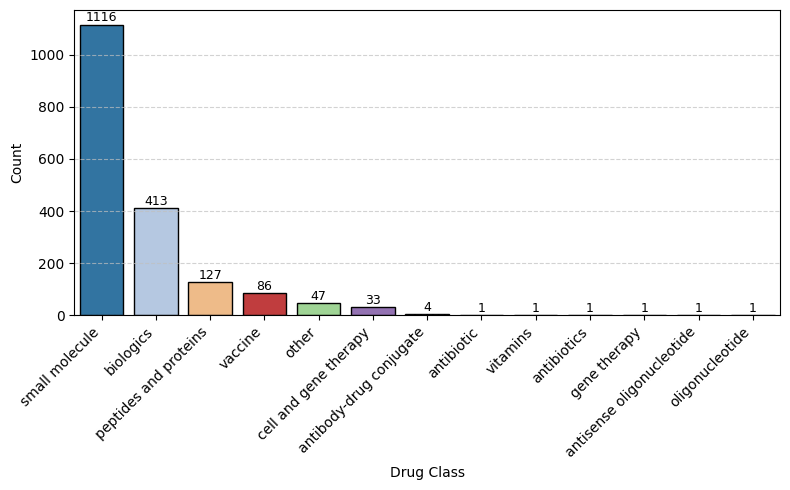

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_25088\3109909329.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


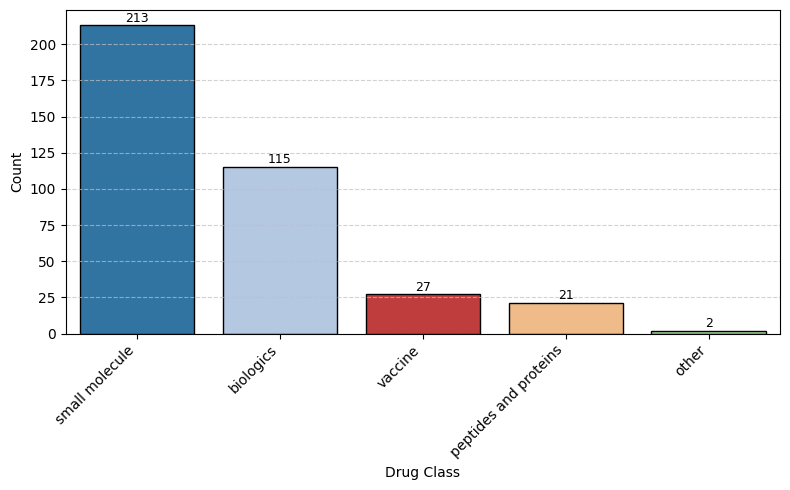

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_25088\3109909329.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


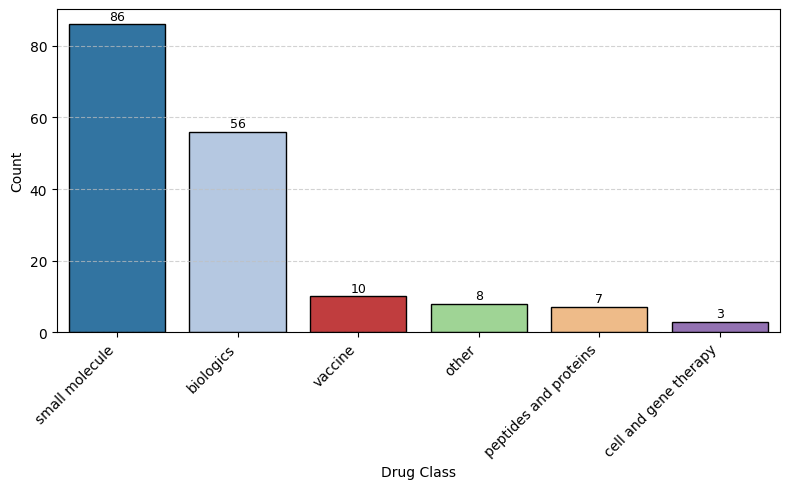

In [415]:
plot_drug_class_distribution(EMA, drug_class_colormap, dataset_name='EMA')
plot_drug_class_distribution(JAPAN, drug_class_colormap, dataset_name='JAPAN')
plot_drug_class_distribution(SWISSMEDIC, drug_class_colormap, dataset_name='SWISSMEDIC')

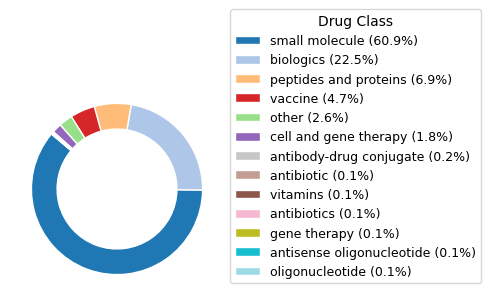

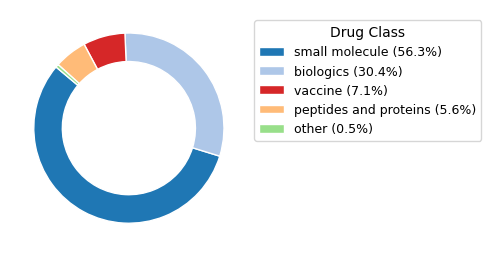

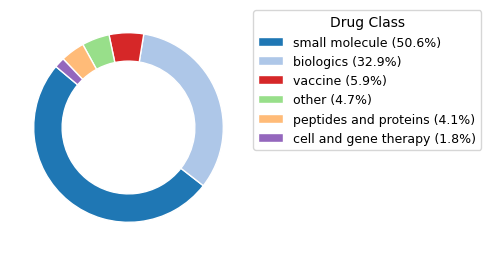

In [416]:
plot_drug_class_distribution_pie(EMA, drug_class_colormap, dataset_name='EMA')
plot_drug_class_distribution_pie(JAPAN, drug_class_colormap, dataset_name='JAPAN')
plot_drug_class_distribution_pie(SWISSMEDIC, drug_class_colormap, dataset_name='SWISSMEDIC')